# 01 — Data Exploration

# Predicting Gallstone Disease from Clinical + Bioimpedance

**Domain:** Healthcare | **Task:** Binary Classification | **Data:** Tabular  
**Dataset:** `data/dataset-uci.csv`  
**Target column:** `Gallstone Status` (Yes[1]/No[0])

Run the cells top-to-bottom. These notebooks avoid seaborn per instructions and use pure matplotlib for charts.

## Objectives
- Verify schema, types, and target encoding
- Basic summary stats and distributions
- Class balance check
- Correlations overview

In [9]:
# Core setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

data = "../data/raw/dataset-uci.csv"
RANDOM_STATE = 42

# Load
df = pd.read_csv(data)
print(df.shape)
df.head()

(319, 39)


,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,Body Mass Index (BMI),Total Body Water (TBW),Extracellular Water (ECW),Intracellular Water (ICW),Extracellular Fluid/Total Body Water (ECF/TBW),Total Body Fat Ratio (TBFR) (%),Lean Mass (LM) (%),Body Protein Content (Protein) (%),Visceral Fat Rating (VFR),Bone Mass (BM),Muscle Mass (MM),Obesity (%),Total Fat Content (TFC),Visceral Fat Area (VFA),Visceral Muscle Area (VMA) (Kg),Hepatic Fat Accumulation (HFA),Glucose,Total Cholesterol (TC),Low Density Lipoprotein (LDL),High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
0,0,50,0,0,0,0,0,0,185,92.8,27.1,52.9,21.2,31.7,40.0,19.2,80.84,18.88,9,3.7,71.4,23.4,17.8,10.6,39.7,0,102.0,250.0,175.0,40.0,134.0,20.0,22.0,87.0,0.82,112.47,0.0,16.0,33.0
1,0,47,0,1,0,0,0,0,176,94.5,30.5,43.1,19.5,23.6,45.0,32.8,67.20,16.68,15,3.2,60.3,38.8,31.0,18.4,32.7,0,94.0,172.0,108.0,43.0,103.0,14.0,13.0,46.0,0.87,107.10,0.0,14.4,25.0
2,0,61,0,0,0,0,0,0,171,91.1,31.2,47.2,20.1,27.1,43.0,27.3,72.67,16.35,15,3.3,62.9,41.7,24.9,16.2,34.0,0,103.0,179.0,124.0,43.0,69.0,18.0,14.0,66.0,1.25,65.51,0.0,16.2,30.2
3,0,41,0,0,0,0,0,0,168,67.7,24.0,41.4,17.0,24.4,41.0,15.8,84.19,16.90,6,2.9,54.1,9.0,10.7,6.5,29.2,1,69.0,173.0,73.0,59.0,53.0,20.0,12.0,34.0,1.02,94.10,0.0,15.4,35.4
4,0,42,0,0,0,0,0,0,178,89.6,28.3,51.4,20.0,31.4,39.0,20.0,80.02,16.81,8,3.5,68.2,28.6,17.9,10.4,37.4,2,109.0,205.0,154.0,30.0,326.0,27.0,54.0,71.0,0.82,112.47,0.0,16.8,40.6


## Inspect dtypes, missingness (should be none per description)

In [10]:
df.info()
df.isna().sum().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 39 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Gallstone Status                                319 non-null    int64  
 1   Age                                             319 non-null    int64  
 2   Gender                                          319 non-null    int64  
 3   Comorbidity                                     319 non-null    int64  
 4   Coronary Artery Disease (CAD)                   319 non-null    int64  
 5   Hypothyroidism                                  319 non-null    int64  
 6   Hyperlipidemia                                  319 non-null    int64  
 7   Diabetes Mellitus (DM)                          319 non-null    int64  
 8   Height                                          319 non-null    int64  
 9   Weight                                     

np.int64(0)

## Peek at basic statistics

In [11]:
df.describe(include='all')

,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,Body Mass Index (BMI),Total Body Water (TBW),Extracellular Water (ECW),Intracellular Water (ICW),Extracellular Fluid/Total Body Water (ECF/TBW),Total Body Fat Ratio (TBFR) (%),Lean Mass (LM) (%),Body Protein Content (Protein) (%),Visceral Fat Rating (VFR),Bone Mass (BM),Muscle Mass (MM),Obesity (%),Total Fat Content (TFC),Visceral Fat Area (VFA),Visceral Muscle Area (VMA) (Kg),Hepatic Fat Accumulation (HFA),Glucose,Total Cholesterol (TC),Low Density Lipoprotein (LDL),High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
count,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.00000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000
mean,0.495298,48.068966,0.492163,0.335423,0.037618,0.028213,0.025078,0.134796,167.15674,80.564890,28.877116,40.587774,17.071160,23.634483,42.212038,28.274984,71.638245,15.938809,9.078370,2.803292,54.273041,35.850125,23.487774,12.171599,30.403448,1.150470,108.688715,203.495298,126.652351,49.475549,144.502163,21.684953,26.855799,73.112539,0.800611,100.818903,1.853856,14.418182,21.401411
std,0.500763,12.114558,0.500724,0.517340,0.190568,0.165841,0.156609,0.342042,10.05303,15.709069,5.313707,7.930235,3.161857,5.349332,3.244470,8.444417,8.437598,2.334744,4.332501,0.509467,10.603833,109.799718,9.607607,5.262178,4.460530,1.059217,44.848714,45.758501,38.541175,17.718701,97.904493,16.697605,27.884413,24.181069,0.176433,16.971396,4.989591,1.775815,9.981659
min,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,145.00000,42.900000,17.400000,13.000000,9.000000,13.800000,29.230000,6.300000,48.990000,5.560000,1.000000,1.400000,4.700000,0.400000,3.100000,0.900000,18.900000,0.000000,69.000000,60.000000,11.000000,25.000000,1.390000,8.000000,3.000000,7.000000,0.460000,10.600000,0.000000,8.500000,3.500000
25%,0.000000,38.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,159.50000,69.600000,25.250000,34.200000,14.800000,19.300000,40.075000,22.025000,65.165000,14.465000,6.000000,2.400000,45.800000,13.900000,17.000000,8.570000,27.250000,0.000000,92.000000,172.000000,100.500000,40.000000,83.000000,15.000000,14.250000,58.000000,0.650000,94.170000,0.000000,13.300000,13.250000
50%,0.000000,49.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,168.00000,78.800000,28.300000,39.800000,17.100000,23.000000,42.000000,27.820000,72.110000,15.870000,9.000000,2.800000,53.900000,25.600000,22.600000,11.590000,30.408108,1.000000,98.000000,198.000000,122.000000,46.500000,119.000000,18.000000,19.000000,71.000000,0.790000,104.000000,0.215000,14.400000,22.000000
75%,1.000000,56.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,175.00000,91.250000,31.850000,47.000000,19.400000,27.550000,44.000000,34.810000,77.850000,17.430000,12.000000,3.200000,62.600000,41.750000,28.550000,15.100000,33.800000,2.000000,109.000000,233.000000,151.000000,56.000000,172.000000,23.000000,30.000000,86.000000,0.920000,110.745000,1.615000,15.700000,28.060000
max,1.000000,96.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,191.00000,143.500000,49.700000,66.200000,27.800000,57.100000,52.000000,50.920000,93.670000,24.810000,31.000000,4.000000,78.800000,1954.000000,62.500000,41.000000,41.100000,4.000000,575.000000,360.000000,293.000000,273.000000,838.000000,195.000000,372.000000,197.000000,1.460000,132.000000,43.400000,18.800000,53.100000


## Target encoding preview & class balance

In [12]:
# Ensure target exists and check encoding
assert "Gallstone Status" in df.columns, "Target column 'Gallstone Status' not found."

target_raw_counts = df["Gallstone Status"].value_counts()
print("Raw target counts (already numeric 0/1):\n", target_raw_counts)
print(f"\nClass balance: {target_raw_counts[0]} No (0), {target_raw_counts[1]} Yes (1)")

Raw target counts (already numeric 0/1):
 Gallstone Status
0    161
1    158
Name: count, dtype: int64

Class balance: 161 No (0), 158 Yes (1)


## Histograms for selected numeric features

Numeric columns: 39


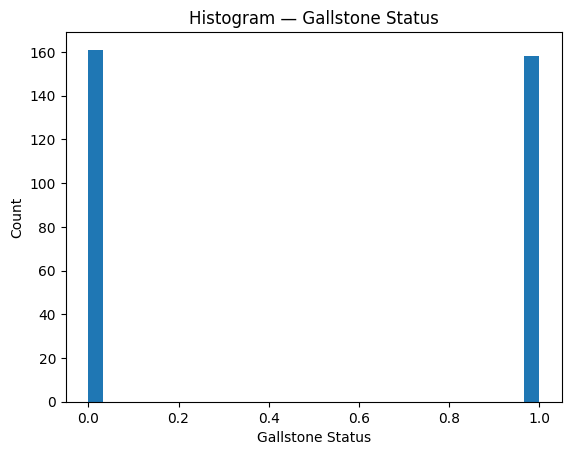

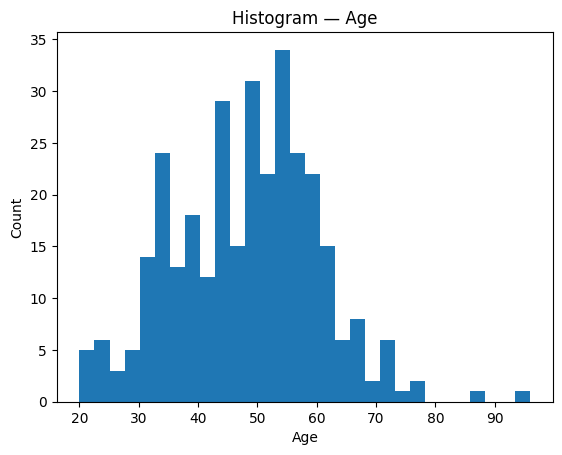

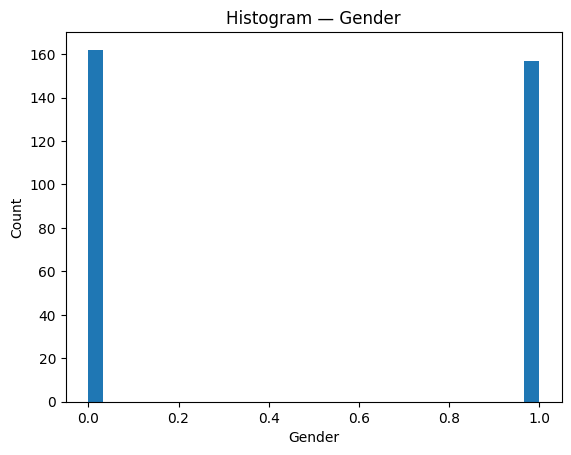

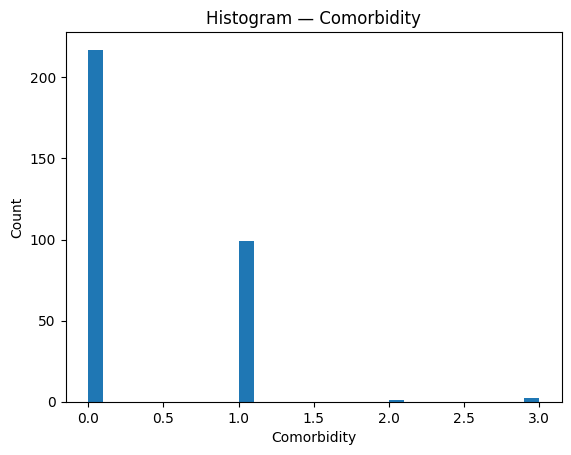

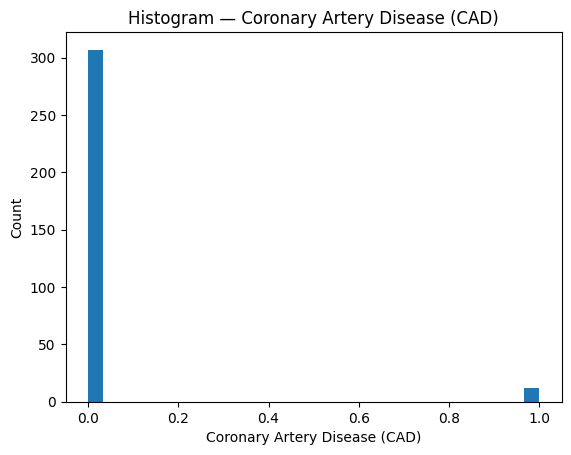

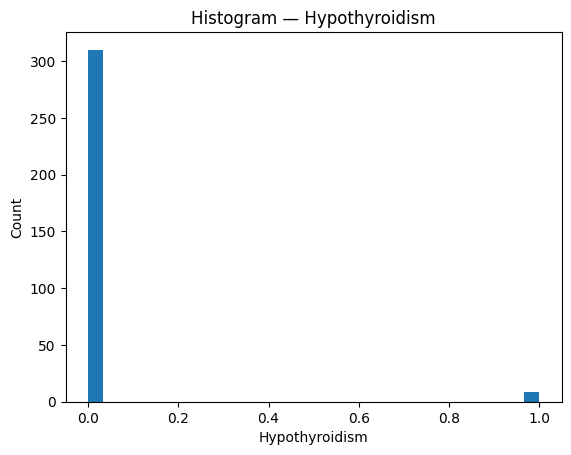

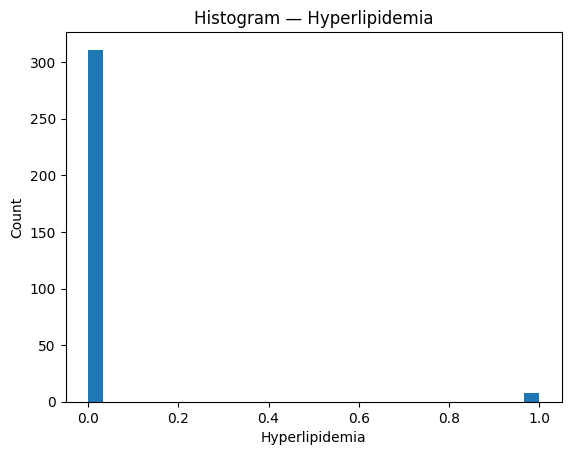

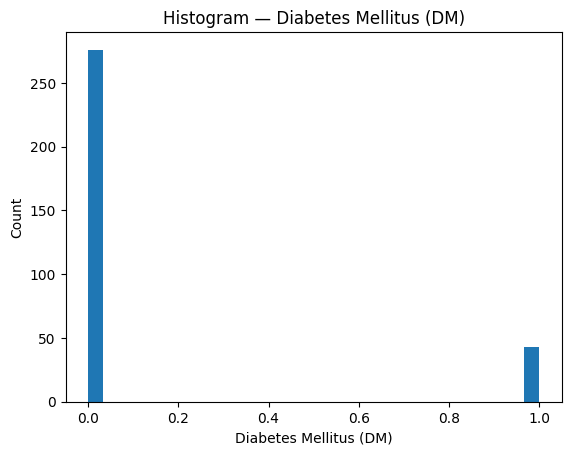

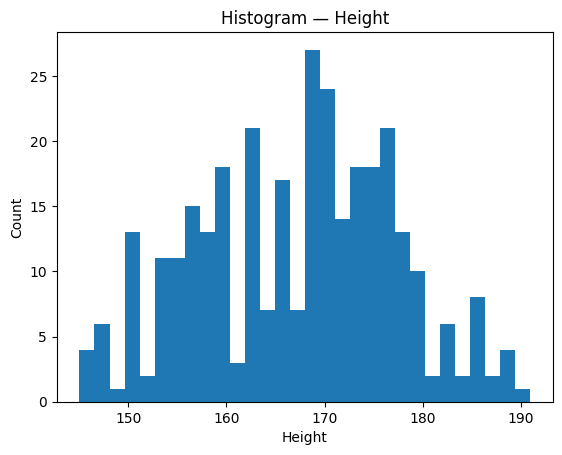

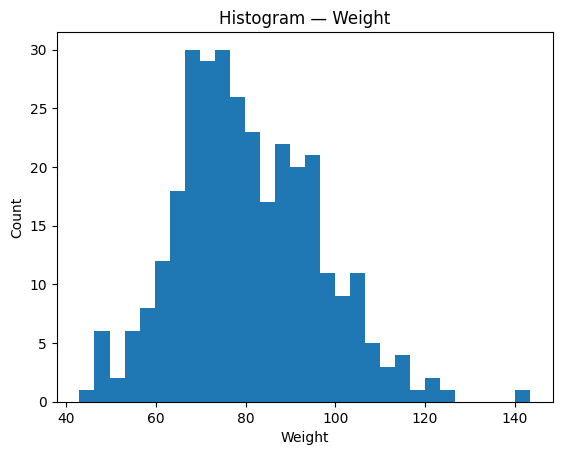

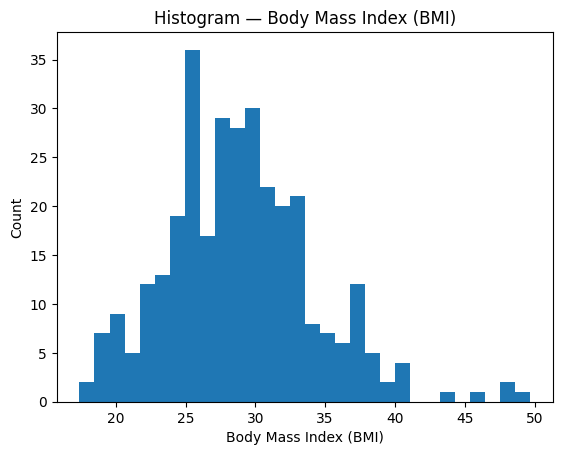

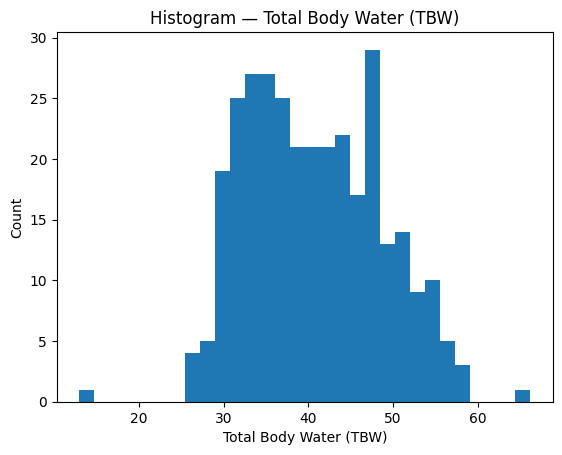

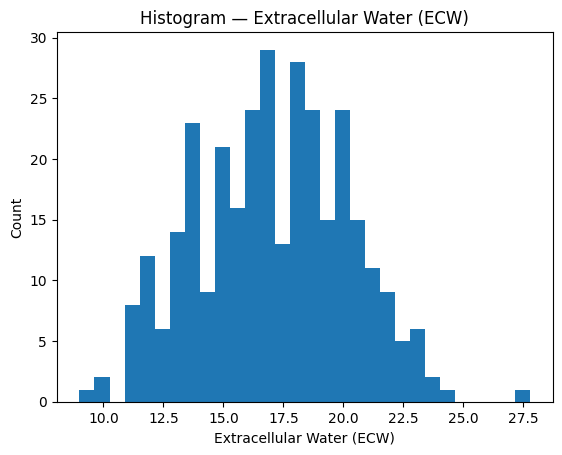

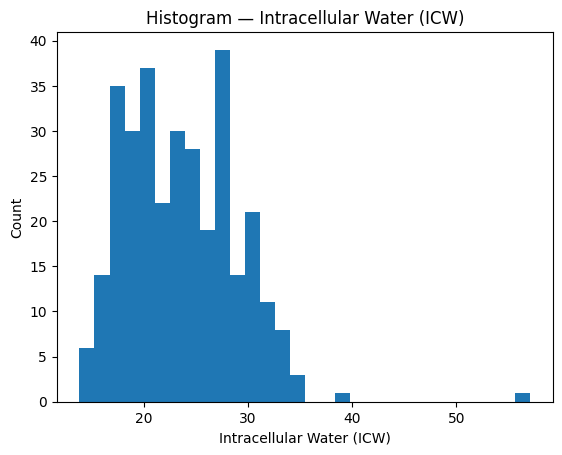

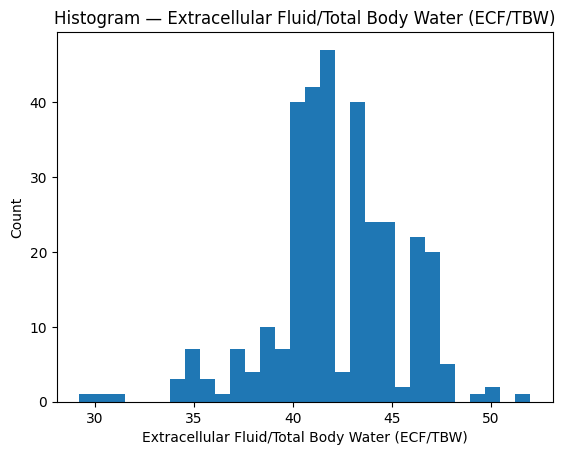

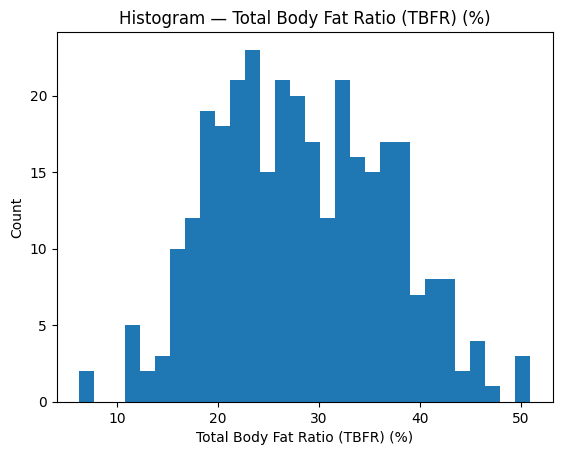

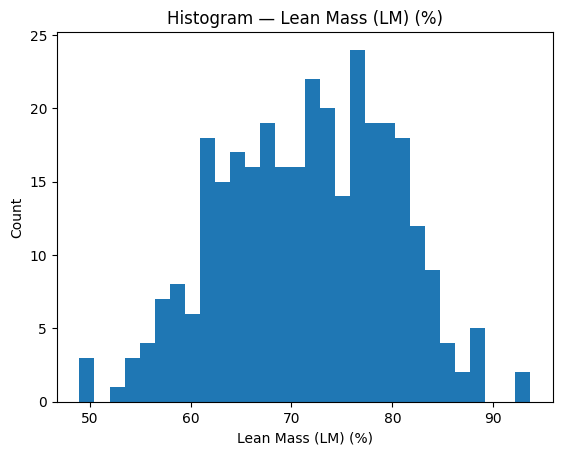

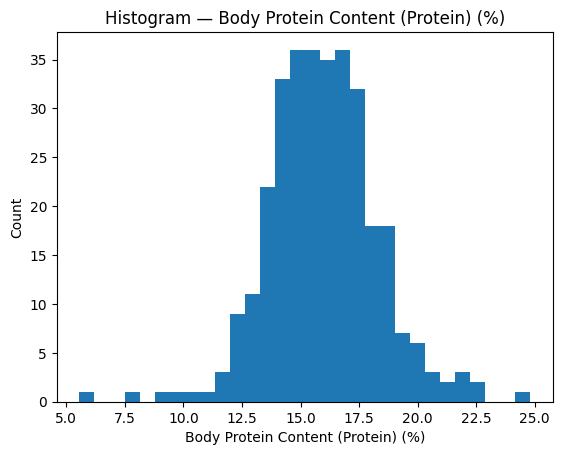

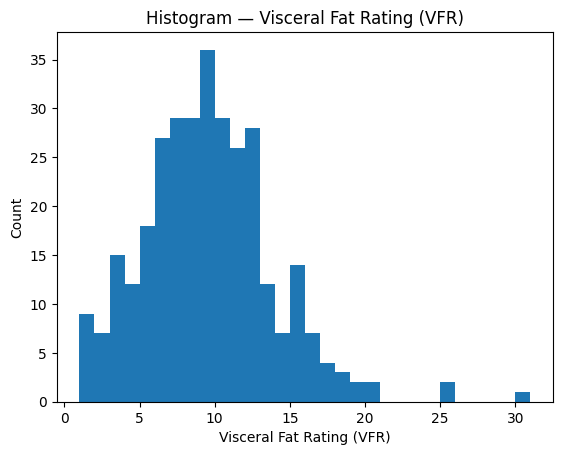

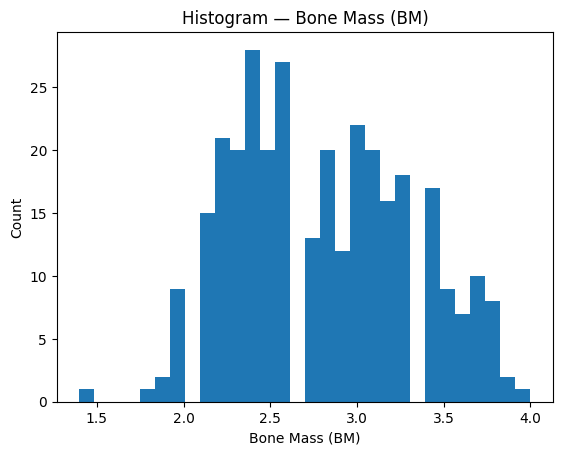

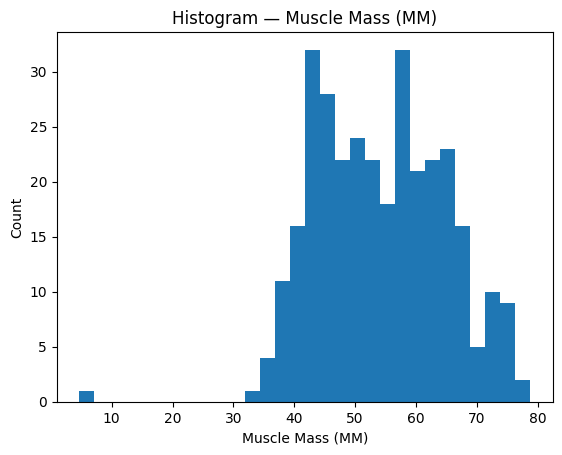

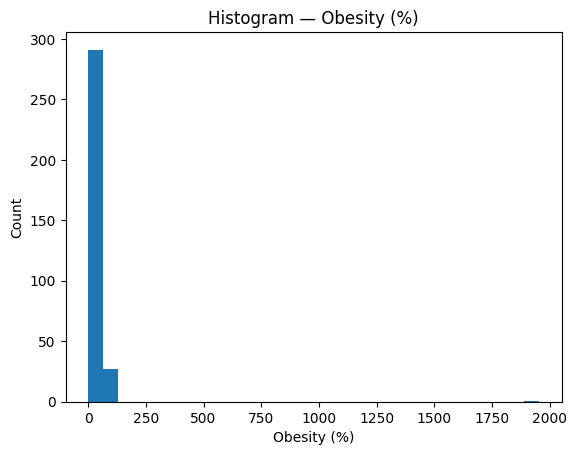

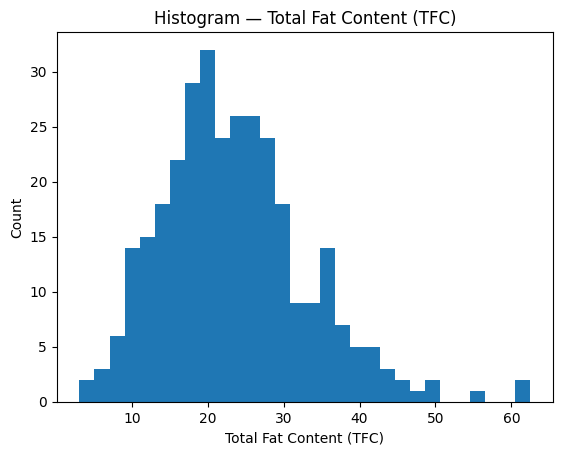

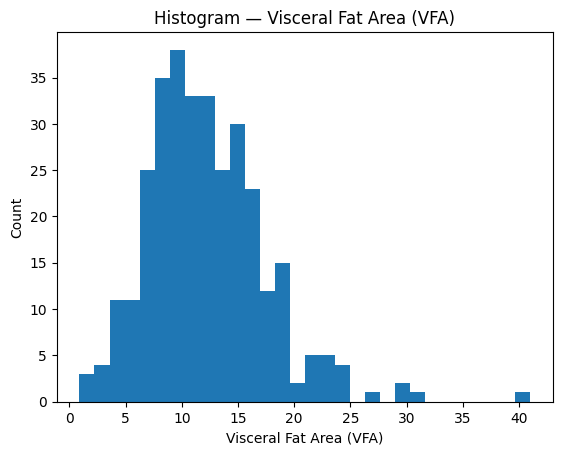

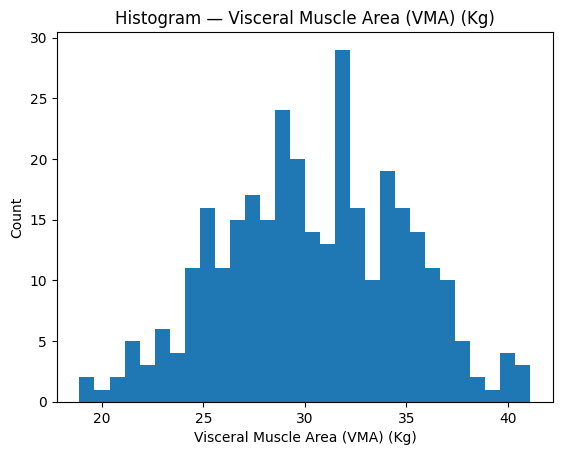

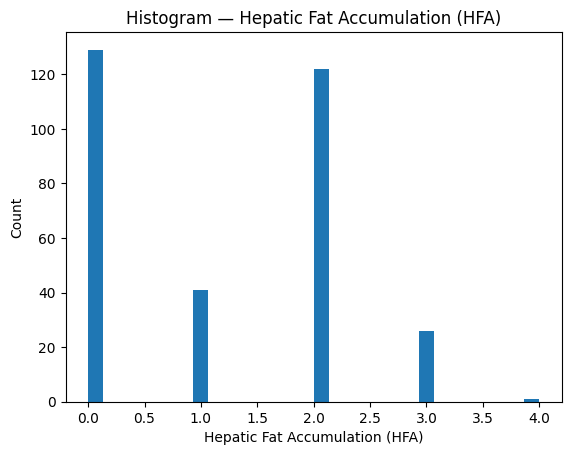

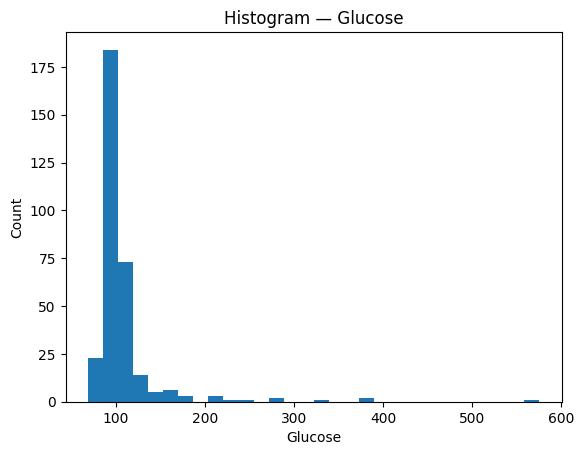

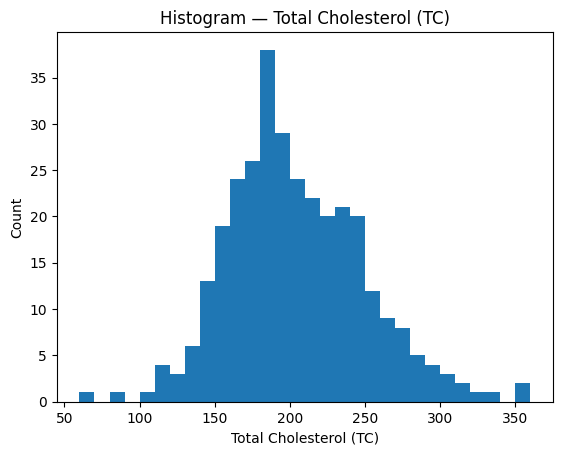

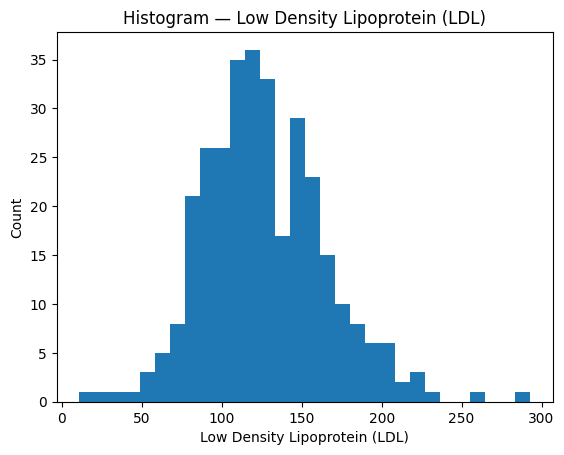

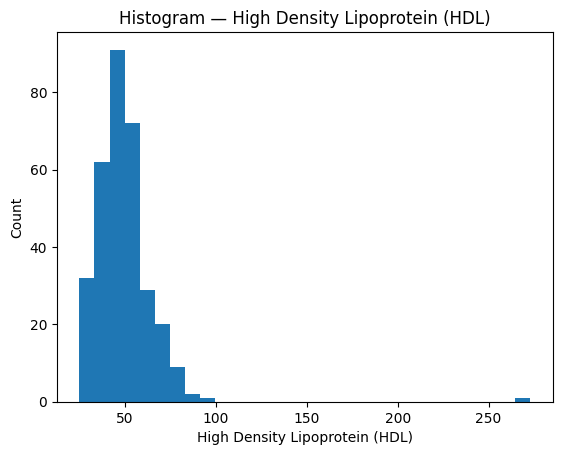

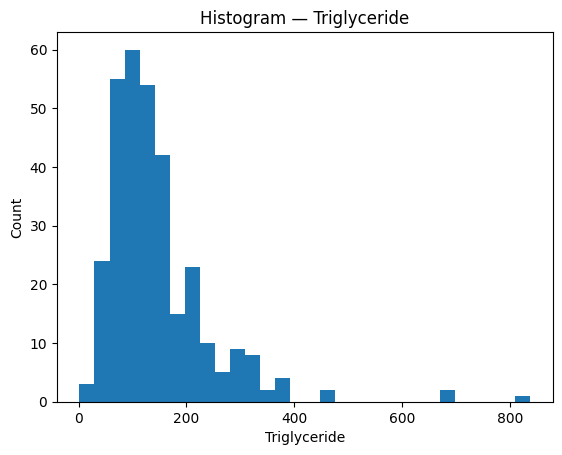

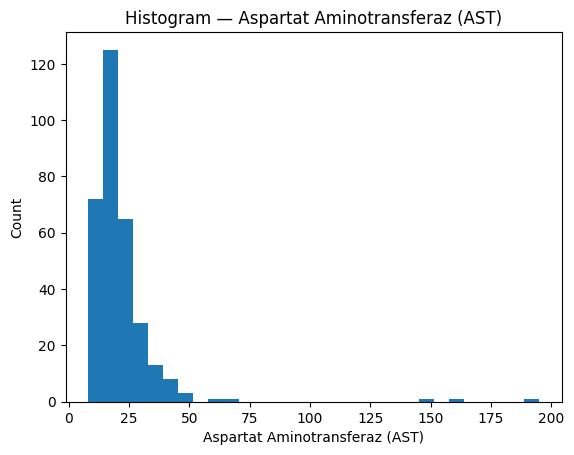

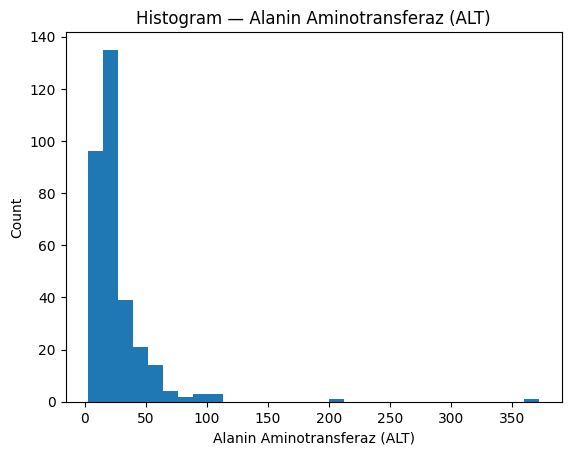

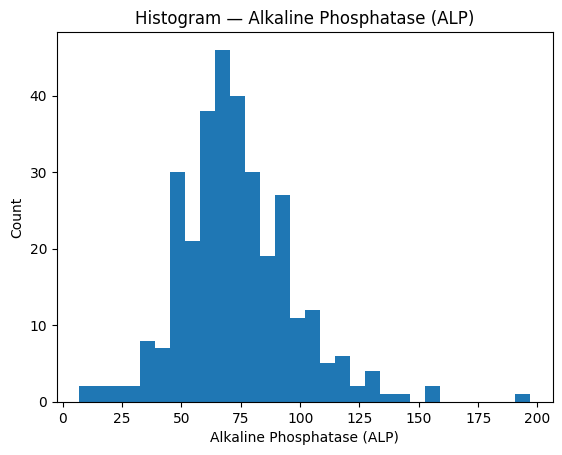

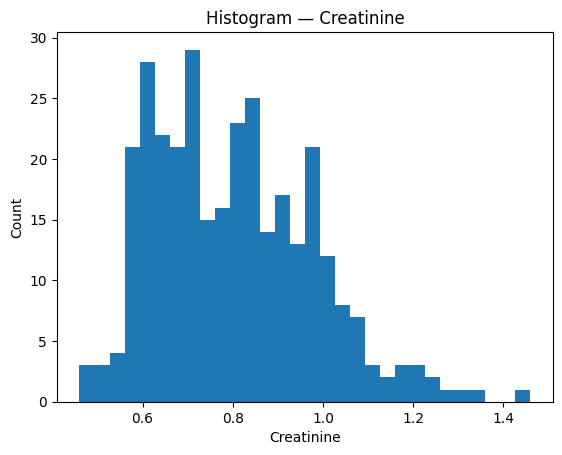

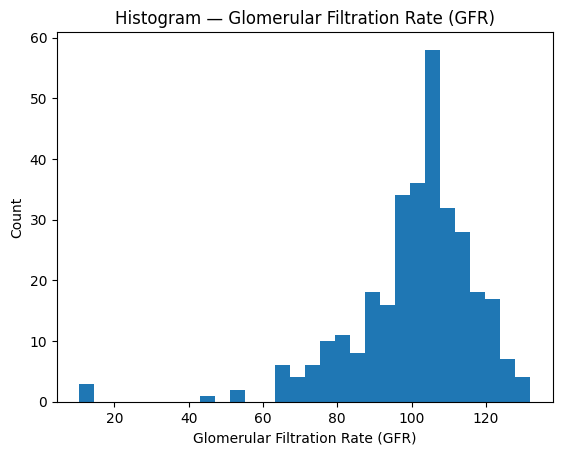

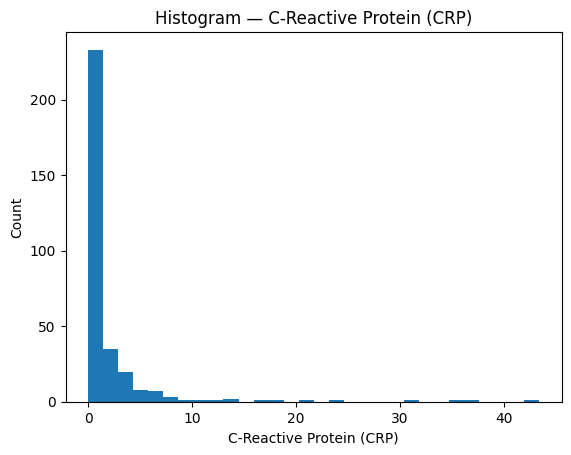

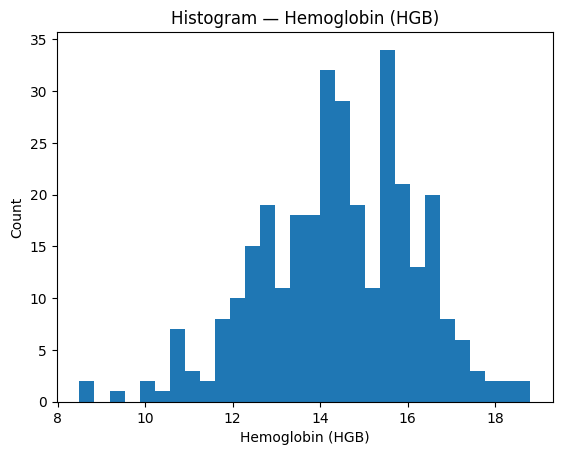

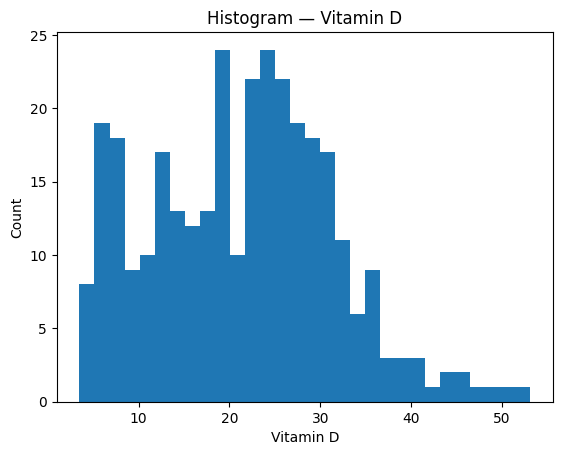

In [13]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", len(numeric_cols))

for col in numeric_cols:
    plt.figure()
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Histogram — {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

## Correlation matrix (numeric features only)

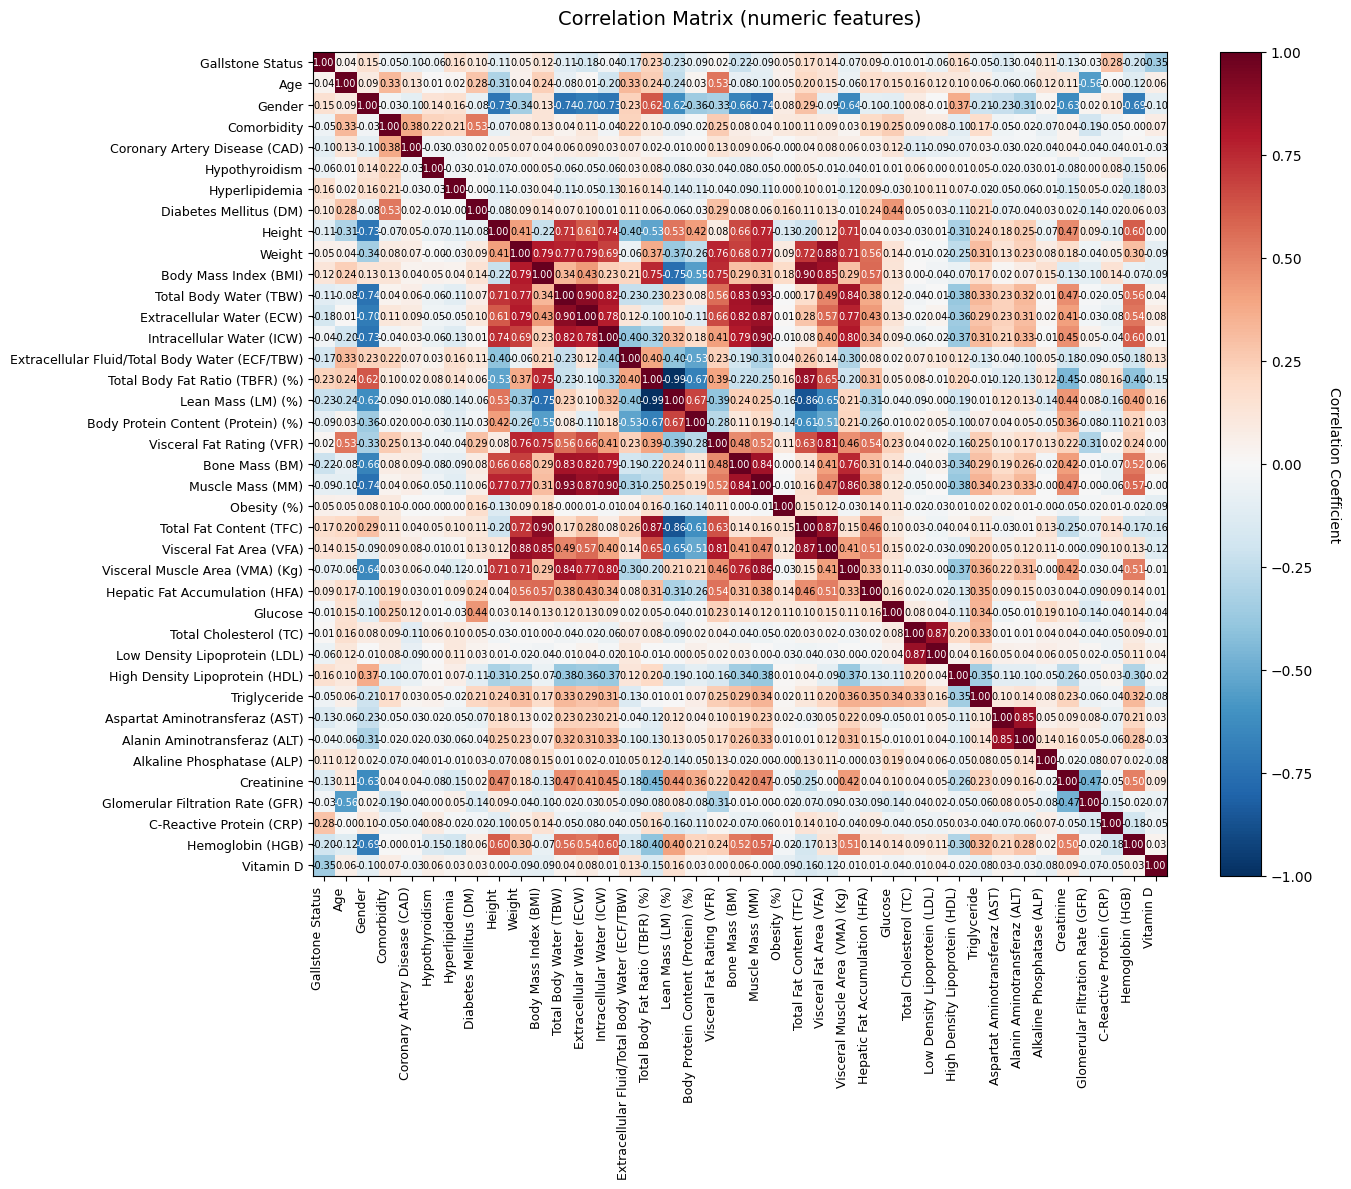

In [14]:
corr = df.select_dtypes(include=[np.number]).corr()
# corr = abs(corr)  # Absolute correlation values

# Create larger figure with better formatting
fig, ax = plt.subplots(figsize=(14, 12))

# Use imshow with better color mapping
im = ax.imshow(corr, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Correlation Coefficient', rotation=270, labelpad=20)

# Set ticks and labels
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, ha='right', fontsize=9)
ax.set_yticklabels(corr.columns, fontsize=9)

# Add correlation values in cells
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        text = ax.text(j, i, f'{corr.iloc[i, j]:.2f}',
                      ha="center", va="center", 
                      color="white" if abs(corr.iloc[i, j]) > 0.5 else "black",
                      fontsize=7)

ax.set_title("Correlation Matrix (numeric features)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()


/var/folders/1n/916yypk515j1_yw9pbqh_rmw0000gn/T/ipykernel_3126/3875712630.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


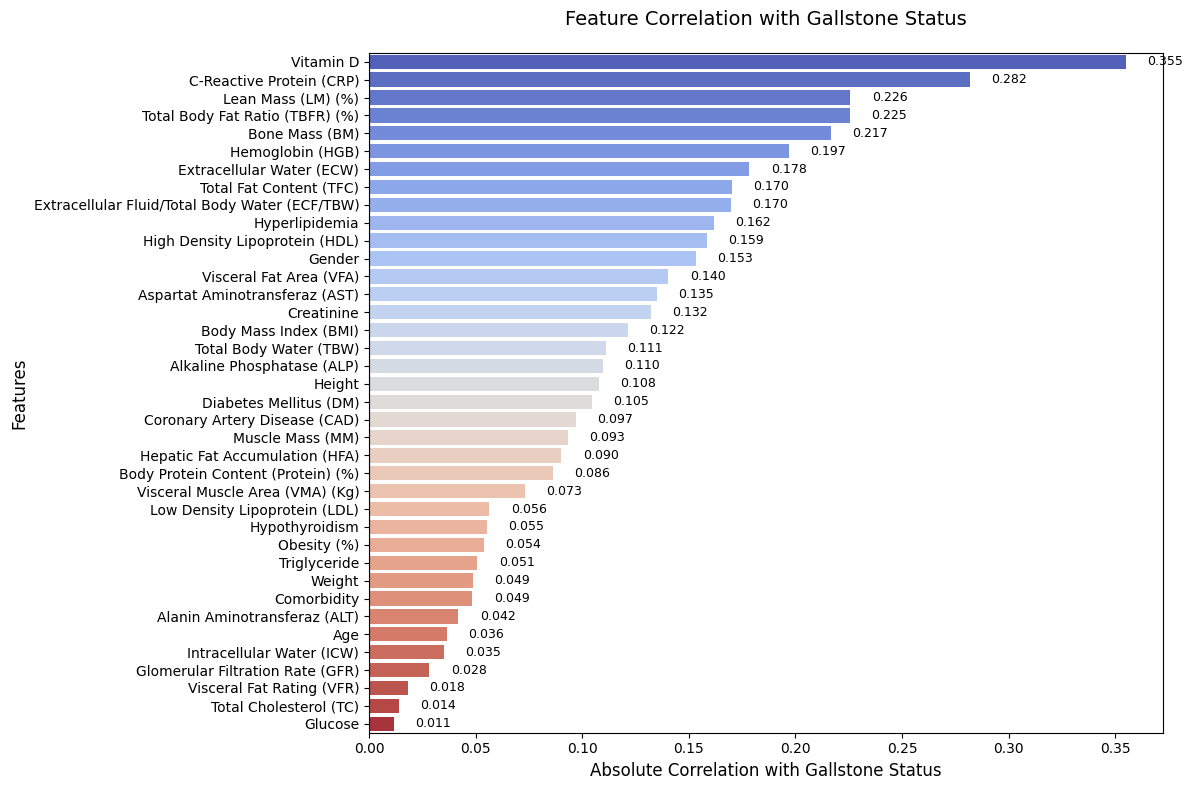


Top 10 features most correlated with Gallstone Status:
Vitamin D                                         0.354873
C-Reactive Protein (CRP)                          0.281995
Lean Mass (LM) (%)                                0.225749
Total Body Fat Ratio (TBFR) (%)                   0.225470
Bone Mass (BM)                                    0.216570
Hemoglobin (HGB)                                  0.196872
Extracellular Water (ECW)                         0.178436
Total Fat Content (TFC)                           0.170158
Extracellular Fluid/Total Body Water (ECF/TBW)    0.169826
Hyperlipidemia                                    0.161901
Name: Gallstone Status, dtype: float64


In [23]:
# Calculate correlation with target variable
target_corr = df.select_dtypes(include=[np.number]).corr()["Gallstone Status"].drop("Gallstone Status")
target_corr_sorted = target_corr.abs().sort_values(ascending=False)

# Create bar plot
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(
    x=target_corr_sorted.values, 
    y=target_corr_sorted.index,
    palette="coolwarm",
    ax=ax
)

ax.set_xlabel("Absolute Correlation with Gallstone Status", fontsize=12)
ax.set_ylabel("Features", fontsize=12)
ax.set_title("Feature Correlation with Gallstone Status", fontsize=14, pad=20)
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)

# Add value labels
for i, v in enumerate(target_corr_sorted.values):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Also show top 10 with actual correlation values (absolute)
print("\nTop 10 features most correlated with Gallstone Status:")
print(target_corr.abs().sort_values(ascending=False).head(10))

## Simple per-class mean comparison (numeric)

In [16]:
df_enc = df.copy()
# Target is already numeric (0/1), no mapping needed
# df_enc["Gallstone Status"] is already 0 or 1

# Check if we have both classes
print("Unique values:", df_enc["Gallstone Status"].unique())
print("Value counts:\n", df_enc["Gallstone Status"].value_counts())

# Group by the numeric target
group_means = df_enc.groupby("Gallstone Status")[numeric_cols].mean().T

# Rename columns for clarity
group_means.columns = ["No (0)", "Yes (1)"]
group_means["diff(Yes-No)"] = group_means["Yes (1)"] - group_means["No (0)"]
group_means.sort_values("diff(Yes-No)", ascending=False)

Unique values: [0 1]
Value counts:
 Gallstone Status
0    161
1    158
Name: count, dtype: int64


,No (0),Yes (1),diff(Yes-No)
Obesity (%),29.994348,41.817089,11.822741
High Density Lipoprotein (HDL),46.695652,52.308228,5.612576
Alkaline Phosphatase (ALP),70.484472,75.790506,5.306034
Total Body Fat Ratio (TBFR) (%),26.391801,30.193924,3.802123
Total Fat Content (TFC),21.870807,25.135443,3.264636
C-Reactive Protein (CRP),0.462174,3.271962,2.809788
Weight,79.808696,81.335443,1.526747
Visceral Fat Area (VFA),11.440870,12.916203,1.475333
Body Mass Index (BMI),28.238509,29.527848,1.289339
Total Cholesterol (TC),202.857143,204.145570,1.288427
